In [1]:
from pathlib import Path
import sys
import os
import warnings

# warnings.filterwarnings("error")
# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))
from scipy.sparse.linalg import eigsh
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import sksparse
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import (
    density_function,
    density_integrals,
    input_statistics_manager,
)
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.amplitude_matrix import isotropic_sphere
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
mat = np.random.randn(100, 100) + 1j * np.random.randn(100, 100)
A_d = mat @ np.conj(mat).T
A_s = scipy.sparse.csc_matrix(A_d)

In [3]:
# Direct cholesky decomps
C_d = np.linalg.cholesky(A_d)
C_s = sksparse.cholmod.cholesky(A_s).L()

diff = C_d - C_s
print(C_d - C_s)
print(np.max(diff))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0j


In [4]:
C_d = matrix_utils.block_cholesky(A_d)
C_s = matrix_utils.block_cholesky_sparse(A_s)

diff = C_d - C_s.todense()
print(diff)
print(np.max(np.abs(diff)))

[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 1.11022302e-16-2.22044605e-16j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-5.55111512e-17+0.00000000e+00j  5.55111512e-17+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 ...
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+2.22044605e-16j ...  2.44249065e-14+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -2.77555756e-17+2.77555756e-17j
   2.77555756e-17+0.00000000e+00j ...  1.66533454e-14+1.77635684e-13j
   2.20046203e-13+0.00000000e+00j  0.00000000e+

/home/nbyrnes/code/random-matrix/random_matrix/utils/matrix_utils.py:577: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T


In [5]:
np.max(C_d @ np.conj(C_d.T) - A_d)

(5.684341886080802e-14+0j)

In [6]:
# Block numpy
C_d_block = matrix_utils.block_cholesky(A_d)

diff = C_d - C_d_block
print(C_d - C_d_block)
print(np.max(np.abs(diff)))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0.0


In [7]:
C_s_1 = sksparse.cholmod.cholesky(A_s).L().toarray()
C_s_2 = sksparse.cholmod.cholesky(A_s, ordering_method="natural").L().toarray()
diff = C_s_1 - C_s_2
print(diff)
print(np.max(np.abs(diff)))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0.0


/tmp/ipykernel_1435423/1721640579.py:12: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T


0j


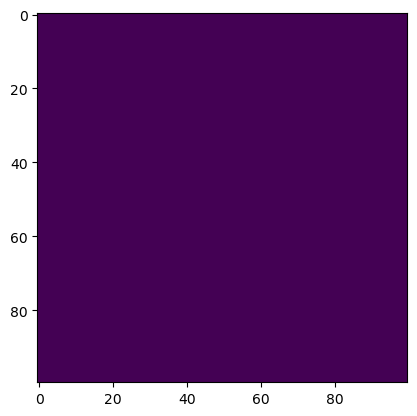

In [8]:
n = A_s.shape[0]
k = n // 2

# Split blocks
A11 = A_s[:k, :k]
A21 = A_s[k:, :k]
A22 = A_s[k:, k:]

# Sparse calculations
A11_factor = sksparse.cholmod.cholesky(A11)
L11 = A11_factor.L()
X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T
S = A22 - X @ X.conj().T
Ls = sksparse.cholmod.cholesky(S).L()

L_top = scipy.sparse.hstack(
    [L11, scipy.sparse.csr_matrix((k, k))], format="csr"
)
L_bottom = scipy.sparse.hstack([X, Ls], format="csr")
L = scipy.sparse.vstack([L_top, L_bottom], format="csr")


diff = L - C_s
plt.imshow(np.abs(diff.todense()))
print(np.max(diff))

In [9]:
print(np.max(L11 @ X - A21.conj().T))

(70.16209827037133-14.62366357577831j)


In [10]:
print(np.min(np.linalg.eigvals(L11.todense())))
# L11_factor = sksparse.cholmod.cholesky(L11).L()
np.max(L11 - L11.T)

(9.516633629765233+0j)


(3.124871261681321+0.07153274192583575j)

In [11]:
L11_container = sksparse.cholmod.cholesky(A11)
L11 = L11_container.L()
L21 = L11_container.solve_A(A21.T.conj()).T.conj()
S = A22 - L21 @ L21.conj().T

L22 = sksparse.cholmod.cholesky(S).L()

# Step 5: Combine blocks
L_top = scipy.sparse.hstack(
    [L11, scipy.sparse.csc_matrix((k, n - k), dtype=A.dtype)]
)
L_bottom = scipy.sparse.hstack([L21, L22])
L = scipy.sparse.vstack([L_top, L_bottom])

/tmp/ipykernel_1435423/585127219.py:3: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  L21 = L11_container.solve_A(A21.T.conj()).T.conj()


NameError: name 'A' is not defined